In [1]:
from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = Path("../data/raw/RML2016.10a/RML2016.10a_dict.pkl")

with open(DATA_PATH, "rb") as f:
    radioml = pickle.load(f, encoding="latin1")

print("Dataset cargado:", len(radioml), "combinaciones")

Dataset cargado: 220 combinaciones


In [21]:
modulation = "QPSK"
snr = 18
sample_index = 0

sample = radioml[(modulation, snr)][sample_index]

I = sample[0]
Q = sample[1]

print("Shape:", sample.shape)

Shape: (2, 128)


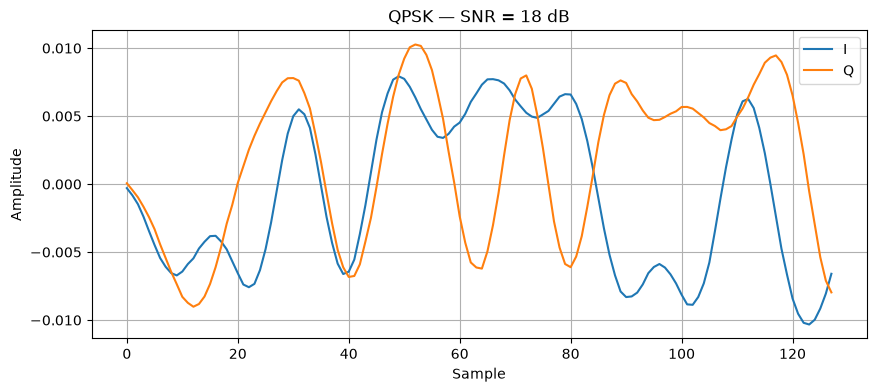

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(I, label="I")
ax.plot(Q, label="Q")

ax.set_title(f"{modulation} — SNR = {snr} dB")
ax.set_xlabel("Sample")
ax.set_ylabel("Amplitude")
ax.legend()
ax.grid(True)

plt.show()

In [23]:
complex_signal = I + 1j * Q

print(complex_signal.shape)
print(complex_signal.dtype)
print(complex_signal[:5])

(128,)
complex64
[-0.00029786+6.2848958e-05j -0.00082597-4.4179478e-04j
 -0.00147865-9.7293709e-04j -0.0023948 -1.6640740e-03j
 -0.00346055-2.4328057e-03j]


In [24]:
magnitude = np.abs(complex_signal)
phase = np.angle(complex_signal)

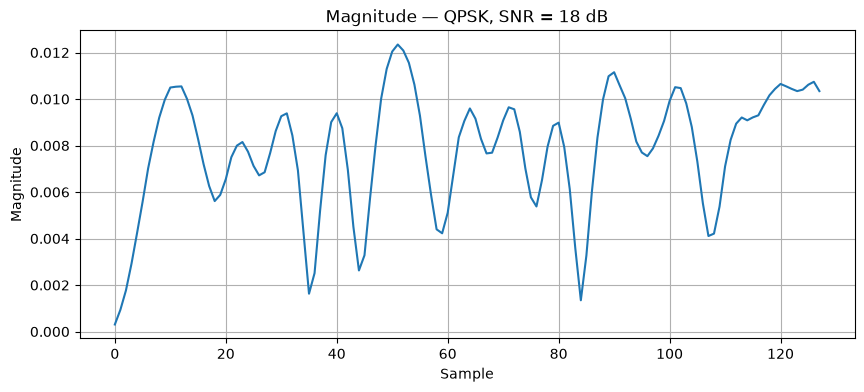

In [25]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(magnitude)

ax.set_title(f"Magnitude — {modulation}, SNR = {snr} dB")
ax.set_xlabel("Sample")
ax.set_ylabel("Magnitude")
ax.grid(True)

plt.show()

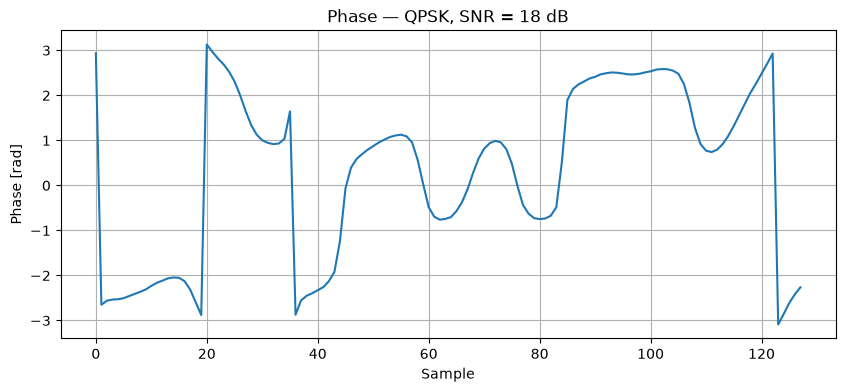

In [26]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(phase)

ax.set_title(f"Phase — {modulation}, SNR = {snr} dB")
ax.set_xlabel("Sample")
ax.set_ylabel("Phase [rad]")
ax.grid(True)

plt.show()

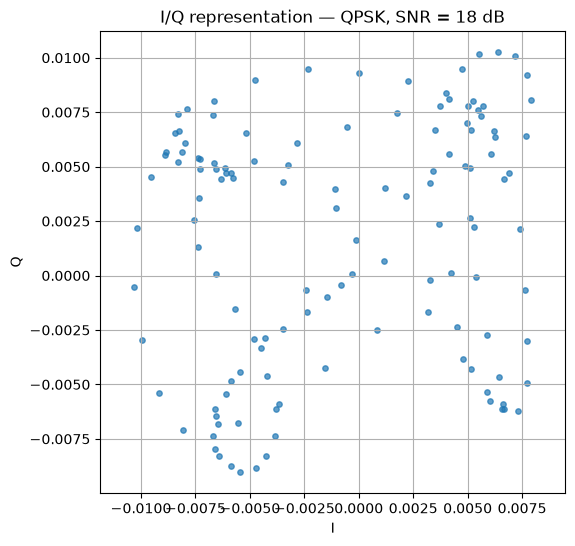

In [27]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(I, Q, s=15, alpha=0.7)

ax.set_title(f"I/Q representation — {modulation}, SNR = {snr} dB")
ax.set_xlabel("I")
ax.set_ylabel("Q")
ax.axis("equal")
ax.grid(True)

plt.show()

In [28]:
from scipy.signal import welch

frequencies, psd = welch(
    complex_signal,
    nperseg=128,
    return_onesided=False
)

frequencies = np.fft.fftshift(frequencies)
psd = np.fft.fftshift(psd)

psd_db = 10 * np.log10(psd + 1e-12)

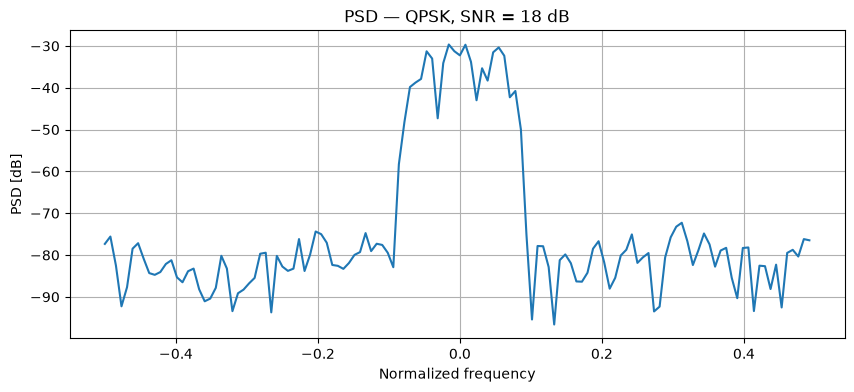

In [29]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(frequencies, psd_db)

ax.set_title(f"PSD — {modulation}, SNR = {snr} dB")
ax.set_xlabel("Normalized frequency")
ax.set_ylabel("PSD [dB]")
ax.grid(True)

plt.show()

In [30]:
def get_signal(radioml, modulation, snr, sample_index=0):
    sample = radioml[(modulation, snr)][sample_index]

    I = sample[0]
    Q = sample[1]
    complex_signal = I + 1j * Q

    return I, Q, complex_signal

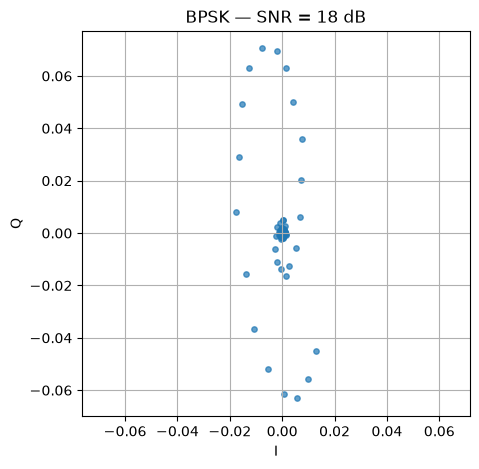

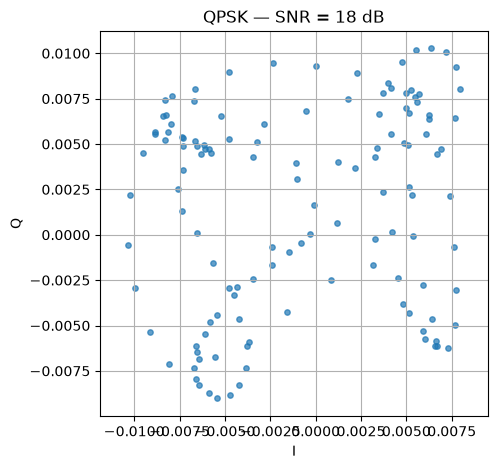

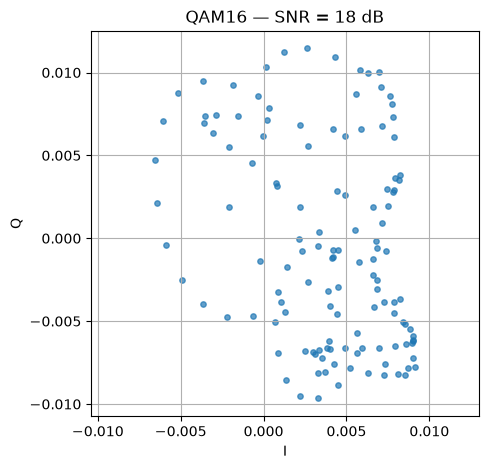

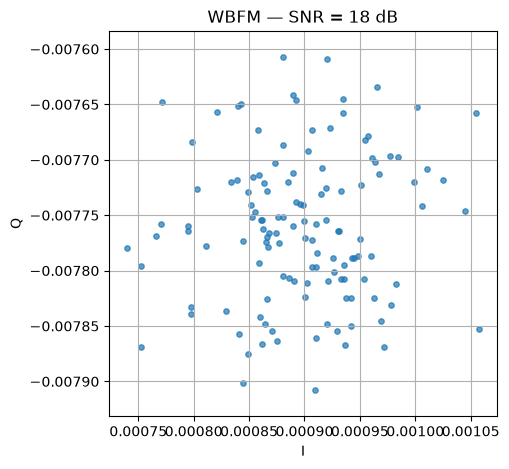

In [31]:
modulations_to_compare = ["BPSK", "QPSK", "QAM16", "WBFM"]
snr = 18

for modulation_name in modulations_to_compare:

    I, Q, complex_signal = get_signal(
        radioml,
        modulation_name,
        snr,
        sample_index=0
    )

    fig, ax = plt.subplots(figsize=(5, 5))

    ax.scatter(I, Q, s=15, alpha=0.7)

    ax.set_title(f"{modulation_name} — SNR = {snr} dB")
    ax.set_xlabel("I")
    ax.set_ylabel("Q")
    ax.axis("equal")
    ax.grid(True)

    plt.show()